<div align="center" style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding:35px;
    border-radius:15px;
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
">
  <h1 style="
      color:white;
      font-family: 'Segoe UI', sans-serif;
      margin:0;
      font-size:42px;
      letter-spacing:1px;
  ">
    Model Selection
  </h1>
</div>

<h3 style="
    text-align:left;
    font-family: 'Georgia', serif;
    font-weight:600;
    letter-spacing:1.5px;
    color:#2c3e50;
">
    🏠 99 Acres by Prince Kumar
</h3>

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor, ExtraTreesRegressor

from sklearn.neural_network import MLPRegressor


from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


In [48]:
import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv(r"C:\Users\Jyoti\99 Acers\Feature_Selection\Gurgaon_Properties_Bining.csv")

In [3]:
df.shape

(2664, 14)

In [4]:
df.head()


,Unnamed: 0,property_name,bedroom,bathroom,configuration,area,area_type,facing,age_possession,property_type,price_cr,sector_encoded,Luxury_category,Floor_category
0,0,Sector 104,2,2,2,1099.0,Super Built-up,North-East,Ready To Move,Flat,1.62,2.838395,Low,High Floor
1,1,Sector 37C,4,4,4,1848.0,Super Built-up,West,Ready To Move,Flat,1.67,1.740714,Low,Low Floor
2,2,Sector 30,4,4,4,5138.0,Carpet,North,Ready To Move,Flat,15.50,9.437500,Low,Low Floor
3,3,Sector 89,3,3,3,1750.0,Built-up,East,Under Construction,Flat,1.70,1.780870,Medium,Low Floor
4,4,Sector 104,4,4,4,3150.0,Super Built-up,Unknown,Ready To Move,Flat,3.80,2.838395,Low,Low Floor


In [5]:
x = df.drop(columns=['price_cr','Unnamed: 0','sector_encoded','Luxury_category','Floor_category','facing'])

In [6]:
x.shape

(2664, 8)

In [7]:
x.head()

,property_name,bedroom,bathroom,configuration,area,area_type,age_possession,property_type
0,Sector 104,2,2,2,1099.0,Super Built-up,Ready To Move,Flat
1,Sector 37C,4,4,4,1848.0,Super Built-up,Ready To Move,Flat
2,Sector 30,4,4,4,5138.0,Carpet,Ready To Move,Flat
3,Sector 89,3,3,3,1750.0,Built-up,Under Construction,Flat
4,Sector 104,4,4,4,3150.0,Super Built-up,Ready To Move,Flat


In [8]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   property_name   2664 non-null   object 
 1   bedroom         2664 non-null   int64  
 2   bathroom        2664 non-null   int64  
 3   configuration   2664 non-null   int64  
 4   area            2664 non-null   float64
 5   area_type       2664 non-null   object 
 6   age_possession  2664 non-null   object 
 7   property_type   2664 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 166.6+ KB


In [9]:
df['bedroom'].unique()

array([ 2,  4,  3,  5,  1,  7,  6, 11, 10, 16, 13, 12,  8, 22,  9, 14, 20,
       18, 35, 30, 17, 36, 32, 23, 48], dtype=int64)

In [55]:
y = df['price_cr']

In [56]:
y_trans = np.log1p(y)

In [57]:
# Y_normal = np.expm1(y_trans)

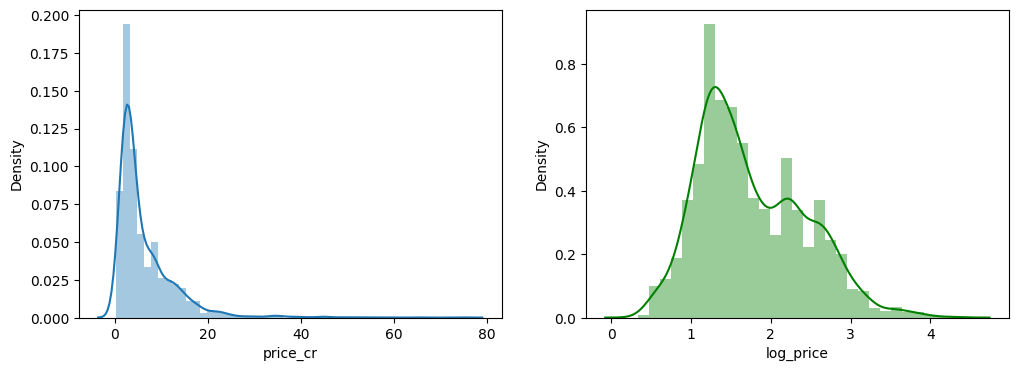

In [58]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.distplot(y)

plt.subplot(1,2,2)
sns.distplot(y_trans,color='green',axlabel='log_price');


# plt.subplot(1,3,3)
# sns.distplot(Y_normal,color='green',axlabel='log_price_to_price_cr')






In [59]:
# I will use Mean Target encoding as Hot encoding will cause Curse of Dimensionality and we have seen it is better than Label encoding.

# Target Encoding

In [60]:
# ! pip install category_encoders

In [61]:
import category_encoders as ce

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['bedroom','bathroom','configuration','area']),
        ('cat',OrdinalEncoder(),['area_type','age_possession','property_type']),
        ('target_enc',ce.TargetEncoder(),'property_name')
    ],
    remainder='passthrough'
)

In [73]:
def scorer(model_name, model):
    
    output = []
    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # K-Fold Cross Validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=2)
    scores = cross_val_score(pipeline, x, y_trans, cv=kfold, scoring='r2')

    output.append(scores.mean())

    # Train Test Split
    x_train, x_test, y_train, y_test = train_test_split(
        x, y_trans, test_size=0.2, random_state=2
    )

    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    # Reverse log transform
    y_pred = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)

    output.append(mean_absolute_error(y_test_actual, y_pred))

    return output

In [74]:
model_dict = {'linear_reg':LinearRegression(),
             'lasso':Lasso(),
             'ridge':Ridge(),
             'SVM':SVR(),
             'Decison_tree': DecisionTreeRegressor(),
             'Random_forest': RandomForestRegressor(),
             'Extra_tree': ExtraTreesRegressor(),
             'Gradient_Boosting':GradientBoostingRegressor(),
             'Ada_Boost': AdaBoostRegressor(),
             'XG_Boost':XGBRegressor(),
             'MLP':MLPRegressor(),
             'Light_gbm':LGBMRegressor(verbose=0),
             'Cat_Boost':CatBoostRegressor(verbose=0)}

In [75]:
model_output = []

for model_name,model in model_dict.items():
    print(f"{model_name} : {model}")
    model_output.append(scorer(model_name,model))

linear_reg : LinearRegression()
lasso : Lasso()
ridge : Ridge()
SVM : SVR()
Decison_tree : DecisionTreeRegressor()
Random_forest : RandomForestRegressor()
Extra_tree : ExtraTreesRegressor()
Gradient_Boosting : GradientBoostingRegressor()
Ada_Boost : AdaBoostRegressor()
XG_Boost : XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None

In [76]:
model_df = pd.DataFrame(model_output,columns=['Name','R2','MAE'])

In [77]:
model_df.sort_values(['MAE'])

,Name,R2,MAE
9,XG_Boost,0.902031,1.089112
5,Random_forest,0.892437,1.192414
6,Extra_tree,0.897153,1.195043
12,Cat_Boost,0.904332,1.255829
11,Light_gbm,0.890888,1.307417
4,Decison_tree,0.847431,1.378413
7,Gradient_Boosting,0.868448,1.568165
3,SVM,0.835138,1.744163
10,MLP,0.834540,1.744691
8,Ada_Boost,0.763263,2.077965


# Hyper Parameter Tuning for Extra tree

In [89]:
from sklearn.model_selection import RandomizedSearchCV

In [90]:
param_grid = {
    'xgb__n_estimators': [300, 500],
    'xgb__learning_rate': [0.03, 0.05, 0.07],
    'xgb__max_depth': [4, 6, 8],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__subsample': [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__reg_alpha': [0, 0.1, 1],
    'xgb__reg_lambda': [1, 2, 5]
}

In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['bedroom','bathroom','configuration','area']),
        ('cat',OrdinalEncoder(),['area_type','age_possession','property_type']),
        ('target_enc',ce.TargetEncoder(),'property_name')
    ],
    remainder='passthrough'
)

In [92]:
pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('xgb',XGBRegressor())
])

In [93]:
kfold = KFold(n_splits=10, shuffle=True, random_state=2)

In [95]:
search = RandomizedSearchCV(pipeline,param_grid,cv=kfold,scoring='r2',n_jobs=-1,verbose=4,n_iter=50)

In [96]:
search.fit(x,y_trans)

Fitting 10 folds for each of 50 candidates, totalling 500 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb__colsample_bytree': [0.7, 0.8], 'xgb__learning_rate': [0.03, 0.05, ...], 'xgb__max_depth': [4, 6, ...], 'xgb__min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [97]:
best = search.best_params_
best

{'xgb__subsample': 0.7,
 'xgb__reg_lambda': 1,
 'xgb__reg_alpha': 0,
 'xgb__n_estimators': 500,
 'xgb__min_child_weight': 1,
 'xgb__max_depth': 8,
 'xgb__learning_rate': 0.07,
 'xgb__colsample_bytree': 0.8}

In [98]:
search.best_score_

0.9074269147112466

In [99]:
finalpipe = search.best_estimator_

In [100]:
finalpipe.fit(x,y_trans)

,steps,"[('preprocessor', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Exporting The Model

In [101]:
import pickle

In [102]:
with open('pipeline.pkl','wb') as file:
    pickle.dump(finalpipe,file)

In [103]:
with open('df.pkl','wb') as file:
    pickle.dump(x,file)

In [104]:
x

,property_name,bedroom,bathroom,configuration,area,area_type,age_possession,property_type
0,Sector 104,2,2,2,1099.0,Super Built-up,Ready To Move,Flat
1,Sector 37C,4,4,4,1848.0,Super Built-up,Ready To Move,Flat
2,Sector 30,4,4,4,5138.0,Carpet,Ready To Move,Flat
3,Sector 89,3,3,3,1750.0,Built-up,Under Construction,Flat
4,Sector 104,4,4,4,3150.0,Super Built-up,Ready To Move,Flat
...,...,...,...,...,...,...,...,...
2659,Block A New Palam Vihar Phase 2,5,5,5,4923.0,Super Built-up,RESALE,House
2660,Sector 10,5,5,5,972.0,Super Built-up,RESALE,House
2661,Sector 109,4,4,4,3600.0,Super Built-up,RESALE,House
2662,Shakti Park Colony,4,2,4,450.0,Super Built-up,RESALE,House


# Voting and Stacking 

In [41]:
from sklearn.ensemble import VotingRegressor, StackingRegressor

In [47]:
voting_model = VotingRegressor(
    estimators=[
        ('extra', ExtraTreesRegressor(max_depth=40,max_features=0.8,min_samples_split=2,min_samples_leaf=1,n_estimators=200)),
        ('xgb', XGBRegressor(random_state=42, verbosity=0)),
        ('cat', CatBoostRegressor(verbose=0, random_state=42))
    ]
)

print(scorer('Voting', voting_model))

['Voting', 0.9056086020202662, 1.123797447933572]


In [48]:
stacking_model = StackingRegressor(
    estimators=[
        ('extra', ExtraTreesRegressor(max_depth=40,max_features=0.8,min_samples_split=2,min_samples_leaf=1,n_estimators=200)),
        ('xgb', XGBRegressor(random_state=42, verbosity=0)),
        ('cat', CatBoostRegressor(verbose=0, random_state=42))
    ],
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)

print(scorer('Stacking', stacking_model))

['Stacking', 0.9048289335959916, 1.130685799091934]
